In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
from lda import LinearDiscriminant as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from exploratory_functions import *
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
%run exploratory_analysis.py

No existe ningún dato faltante.

Distribución de clases:
abandono - 1421 - 32.12%
graduado - 2209 - 49.93%
matriculado - 794 - 17.95%

--- INICIO PREPROCESADO FEATURES ---

[Binarias]
 - asistencia_diurna_vespertina → 0=diurna, 1=vespertina
 - becado → 0=no, 1=si
 - desplazado → 0=no, 1=si
 - deudor → 0=no, 1=si
 - genero → 0=hombre, 1=mujer
 - internacional → 0=no, 1=si
 - matricula_al_dia → 0=no, 1=si
 - necesidades_educativas_especiales → 0=no, 1=si

[Ordinales]
 - cualificacion_previa → escala ordinal educativa
 - cualificacion_madre → escala ordinal educativa
 - cualificacion_padre → escala ordinal educativa

[Categóricas → dummies / reducción]
 - estado_civil → one-hot encoding
 - nacionalidad → binaria (portuguesa vs resto)
 - modo_solicitud → agrupación + one-hot
 - curso → agrupación en categorías + one-hot
 - ocupacion_madre/padre → agrupación por sector + one-hot

[Reducción de variables]
 - ratios académicos (presentación y éxito por semestre)
 - eliminación de variables re

In [4]:
data = pd.read_csv("rendimiento_estudiantes_procesado.csv", sep=";", encoding="utf-8")
y = data["objetivo"]
X = data.drop(columns="objetivo")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, shuffle=True) #permutacion de los datos


#### Debido a la menor cantidad de samples con objetivo: "Matriculados", procedemos a hacer un oversampling del train

In [6]:
X_train, y_train = duplicate_minority_only(X_train, y_train)
print("\nDistribución de clases en TRAIN:")
clases, counts = np.unique(y_train, return_counts=True)
total = len(y_train)
for clase, cantidad in zip(clases, counts):
    porcentaje = cantidad / total * 100
    print(f"Clase {clase}: {cantidad} - Porcentaje: {porcentaje:.2f}%")

print("\nDistribución de clases en TEST:")
clases, counts = np.unique(y_test, return_counts=True)
total = len(y_test)
for clase, cantidad in zip(clases, counts):
    porcentaje = cantidad / total * 100
    print(f"Clase {clase}: {cantidad} - Porcentaje: {porcentaje:.2f}%")


Distribución de clases en TRAIN:
Clase 0: 1137 - Porcentaje: 27.19%
Clase 1: 1759 - Porcentaje: 42.06%
Clase 2: 1286 - Porcentaje: 30.75%

Distribución de clases en TEST:
Clase 0: 284 - Porcentaje: 32.09%
Clase 1: 450 - Porcentaje: 50.85%
Clase 2: 151 - Porcentaje: 17.06%


IMPLEMENTACION Y EVALUACION DE LA TAREA DE CLASIFICACION

In [7]:
lda = LDA()
lda.fit(X_train, y_train)

#### QUEREMOS VISUALIZAR LOS PESOS QUE LDA LE HA ASIGNADO A CADA FEATURE PARA VER CUALES SON MAS IMPORTANTES

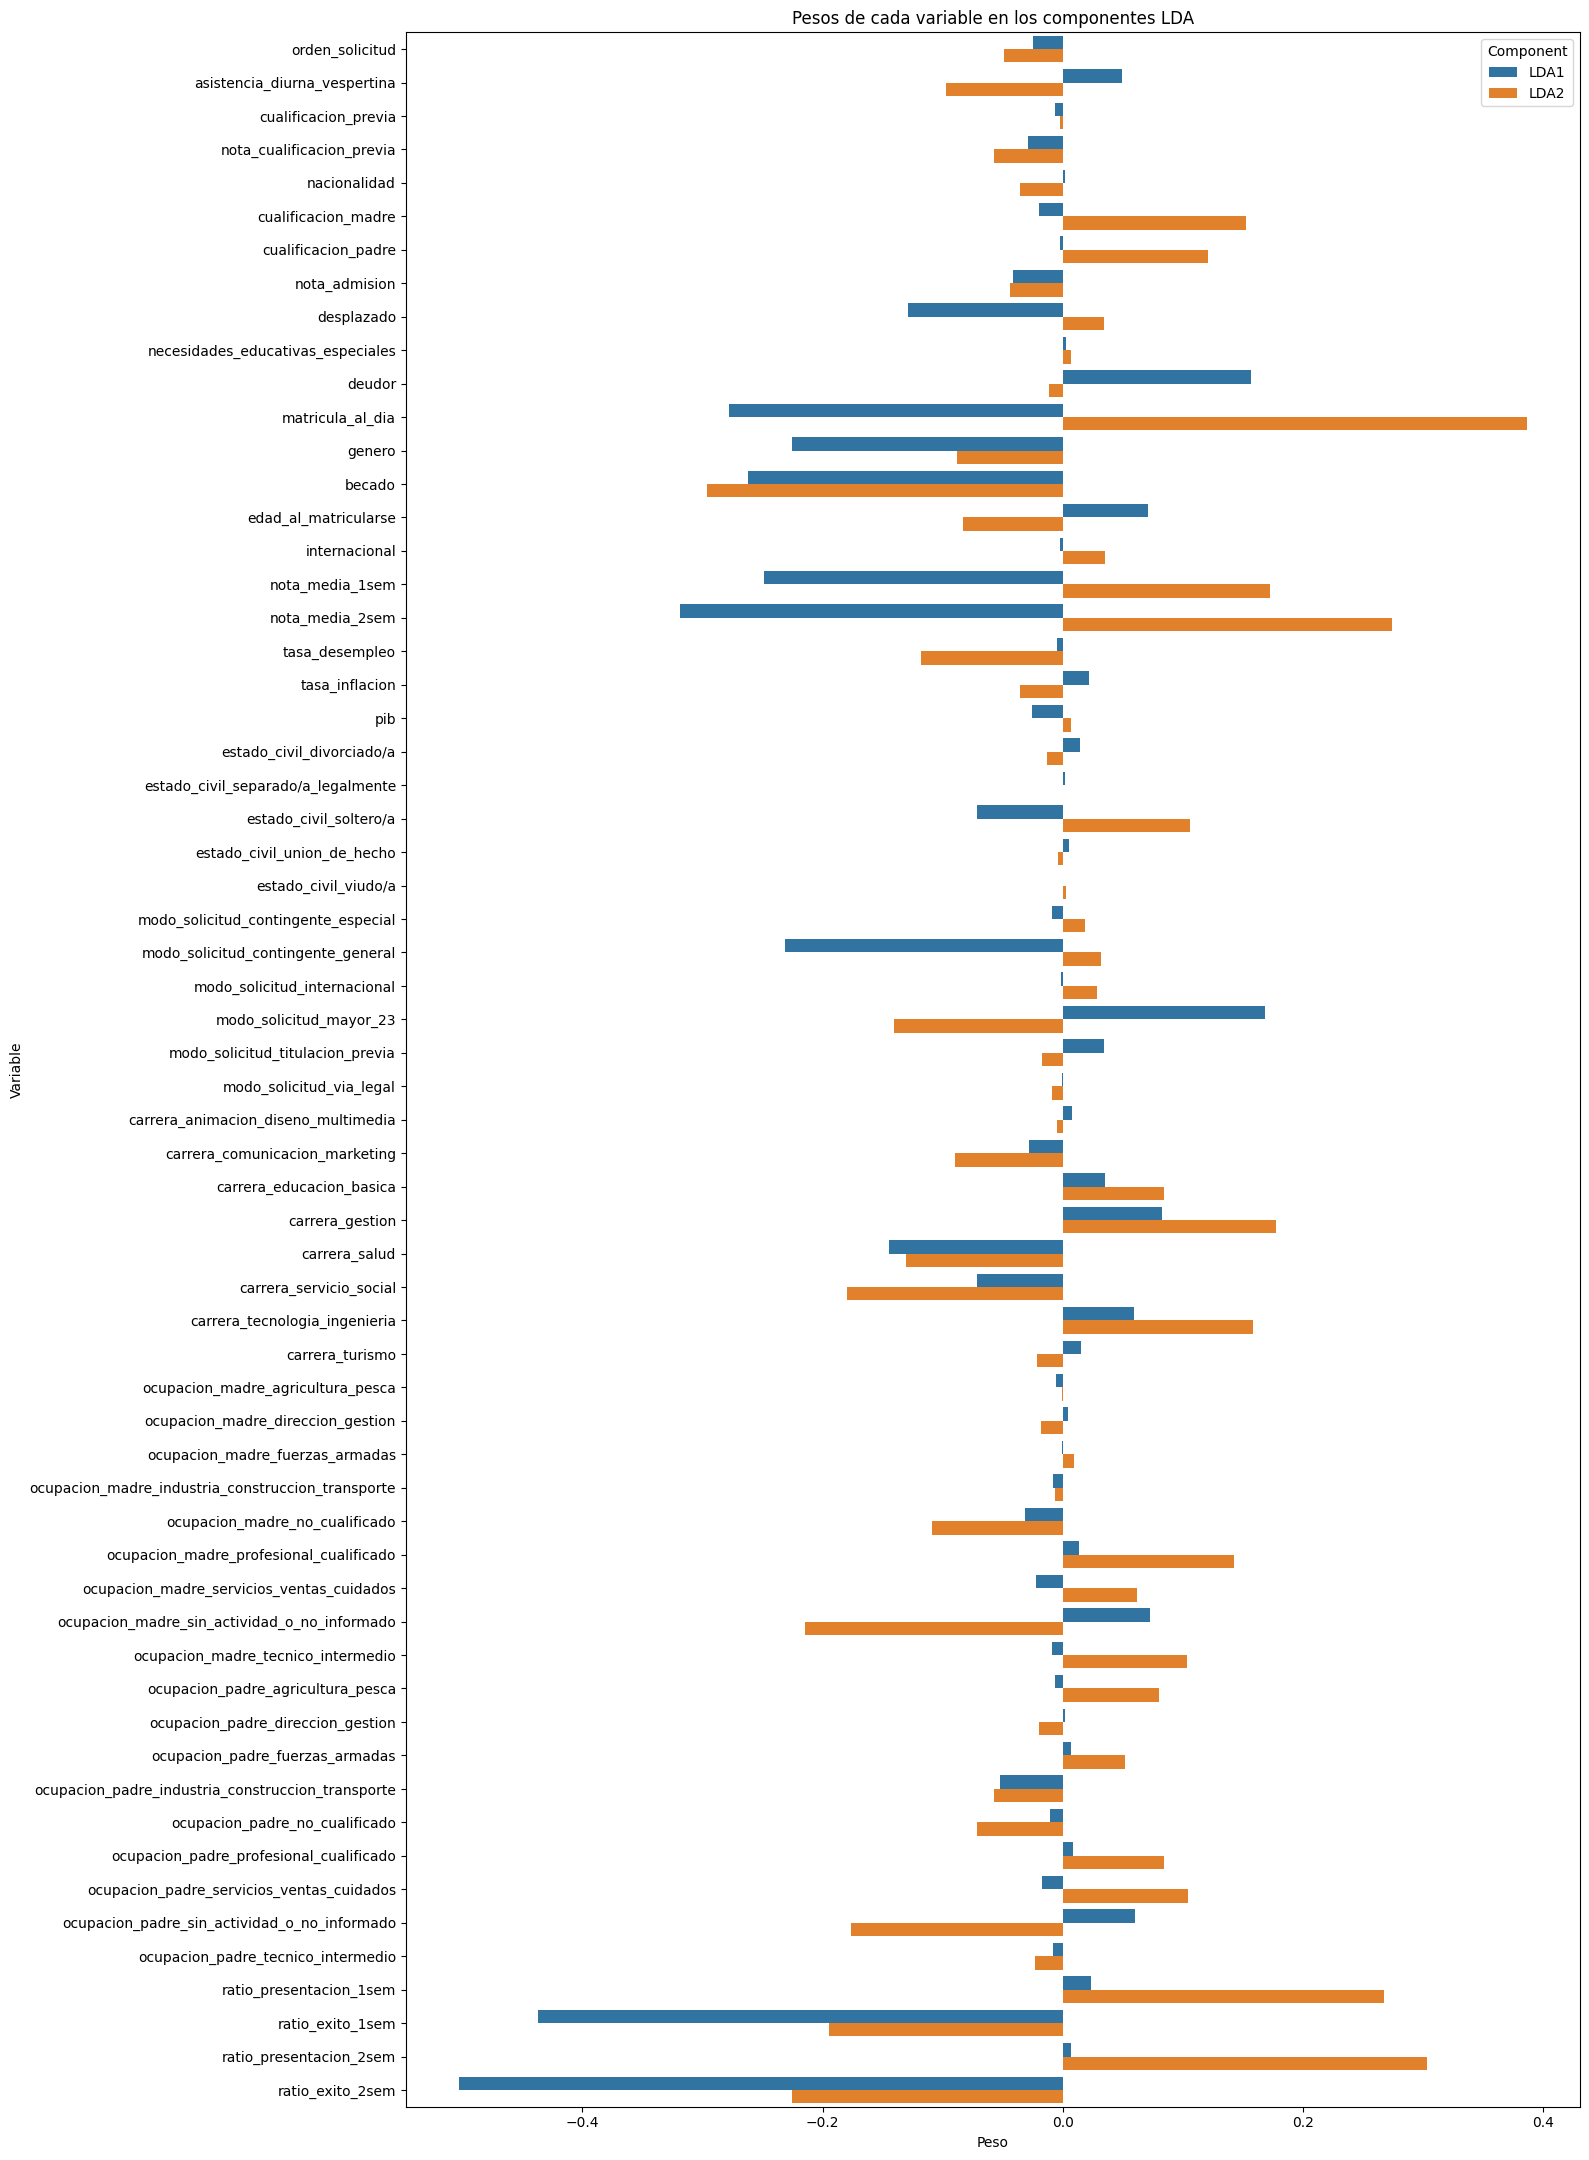

In [8]:
feature_names = X.columns.tolist()

lda_weights = lda.weights

weights_df = pd.DataFrame(
    lda_weights,
    index=feature_names,
    columns=[f"LDA{i+1}" for i in range(lda_weights.shape[1])]
).reset_index()

weights_df = weights_df.rename(columns={"index": "feature"})

weights_melted = weights_df.melt(
    id_vars="feature",
    var_name="Component",
    value_name="Weight"
)

feature_order = feature_names

plt.figure(figsize=(16, max(12, len(feature_names) * 0.35)))
sns.barplot(
    data=weights_melted,
    y="feature",
    x="Weight",
    hue="Component",
    order=feature_order,
    orient="h"
)

plt.title("Pesos de cada variable en los componentes LDA")
plt.xlabel("Peso")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## EVALUAMOS EL MODELO

Accuracy: 0.72


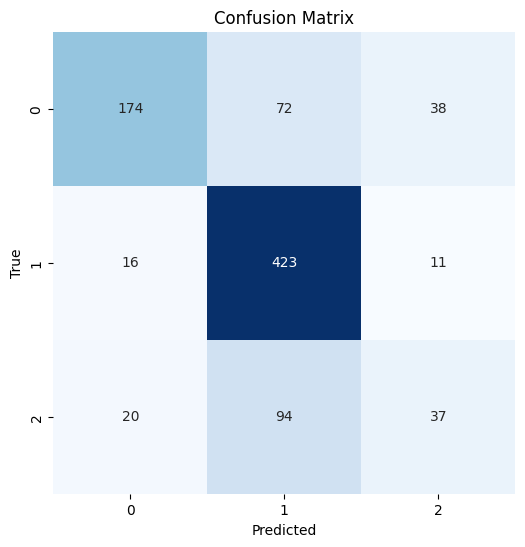

In [9]:
y_pred = lda.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_m = confusion_matrix(y_test, y_pred)

#Display the accuracy
print(f'Accuracy: {accuracy:.2f}')

#Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_m, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()